# Explorative Analyse von Literaturbesprechungen

Dieses Notebook enthält den für eine explorative Analyse basierend auf den Daten der Masterarbeit "Literaturbesprechungen in historischen Zeitungen: Korpusbildung und Analyse diachroner Entwicklungen mit LLMs und NLP-Methoden".

Dabei werden als Vorverarbeitung die in Dictionaries strukturiert vorliegenden Informationen, wie sie im Zuge der Annotation bzw. Anreicherung des Korpus unter Einsatz von LLMs zustande kamen, in jeweils eigene Spalten für jeden Wert überführt. Anschließend werden Visualisierungen über die anteiligen Vorkommen der Werte im Datenset sowie im Zeitverlauf über die Jahrzehnte des 19. Jahrhunderts erstellt.

In [ ]:
import pandas as pd
import re

df_review = pd.read_csv("df_reviews_with_final_dictionaries.csv")

# Hilfsfunktion: extrahiert Inhalt eines Tags
def extract_tag(text, tag):
    if pd.isna(text):
        return None
    pattern = fr"<{tag}>(.*?)</{tag}>"
    match = re.search(pattern, text, re.DOTALL)
    return match.group(1).strip() if match else None

# Spezifisch für verschachtelte Struktur (z.B. author_name innerhalb <author>)
def extract_nested(text, parent, child):
    if pd.isna(text):
        return None
    parent_pattern = fr"<{parent}>(.*?)</{parent}>"
    parent_match = re.search(parent_pattern, text, re.DOTALL)
    if not parent_match:
        return None
    return extract_tag(parent_match.group(1), child)

# Spalten definieren
fields = {
    # sentiment
    "sentiment_overall": lambda x: extract_tag(x, "sentiment_overall"),
    "sentiment_style": lambda x: extract_tag(x, "sentiment_style"),
    "sentiment_content": lambda x: extract_tag(x, "sentiment_content"),
    "sentiment_society": lambda x: extract_tag(x, "sentiment_society"),
    "sentiment_morality": lambda x: extract_tag(x, "sentiment_morality"),
    "sentiment_author": lambda x: extract_tag(x, "sentiment_author"),

    # reviewer
    "reviewer_voice": lambda x: extract_tag(x, "reviewer_voice"),

    # reviewed_work
    "title": lambda x: extract_tag(x, "title"),
    "author_name": lambda x: extract_nested(x, "author", "author_name"),
    "author_gender": lambda x: extract_nested(x, "author", "author_gender"),
    "publisher": lambda x: extract_tag(x, "publisher"),
    "category": lambda x: extract_tag(x, "category"),
    "genre": lambda x: extract_tag(x, "genre"),

    # translation
    "is_translation": lambda x: extract_tag(x, "is_translation"),
    "source_language": lambda x: extract_tag(x, "source_language"),

    # quality_control
    "completeness": lambda x: extract_tag(x, "completeness"),
    "human_verification_needed": lambda x: extract_tag(x, "human_verification_needed"),

    # mentions komplett übernehmen
    "mentions": lambda x: extract_tag(x, "mentions"),
}

# Anwenden
for col, func in fields.items():
    df_review[col] = df_review["final_dictionaries"].apply(func)

# Optional: ursprüngliche Spalte behalten oder droppen
# df_review = df_review.drop(columns=["final_dictionaries"])

print(df_review.head())

                                             page_id  pagenumber  \
0  3SI25BF35ND2DITRZNHTAZPB7NTXANV2-ALTO7267362_D...           4   
1  AMILOILFECYBZRHC5BKCXSM5BN6WTCZZ-ALTO7267913_D...           3   
2  5TX6KA77DYBRICWJOABZOUJ7PXPOTFJY-ALTO7267792_D...           4   
3  2I5SSELJRQLPTPZ4KJKSCQO4QD33VXYN-ALTO11621592_...           8   
4  GIXE74UTQID7VDPIUADOX6ZKJE6XJKNO-ALTO11621627_...           7   

                    paper_title                   provider_ddb_id  \
0  Kölnische Zeitung. 1803-1945  VKNQFFAKOR4XZWJJKUX3NGYSZ3QZAXCW   
1  Kölnische Zeitung. 1803-1945  VKNQFFAKOR4XZWJJKUX3NGYSZ3QZAXCW   
2  Kölnische Zeitung. 1803-1945  VKNQFFAKOR4XZWJJKUX3NGYSZ3QZAXCW   
3  Kölnische Zeitung. 1803-1945  VKNQFFAKOR4XZWJJKUX3NGYSZ3QZAXCW   
4  Kölnische Zeitung. 1803-1945  VKNQFFAKOR4XZWJJKUX3NGYSZ3QZAXCW   

                                            provider     zdb_id  \
0  Universitäts- und Landesbibliothek der Rheinis...  2719361-5   
1  Universitäts- und Landesbibliothek der 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ensure numeric
df_review["year"] = pd.to_numeric(df_review["year"], errors="coerce")

# count per year
year_counts = df_review["year"].value_counts().sort_index()

print(year_counts.head())

year
1815    3
1816    2
1817    2
1819    1
1820    9
Name: count, dtype: int64


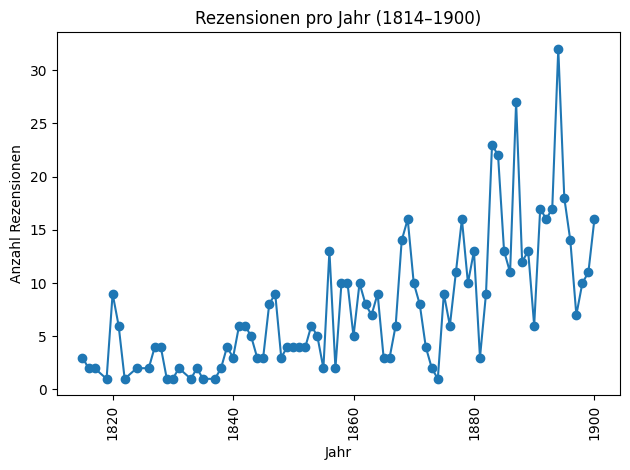

In [ ]:
plt.figure()
year_counts.plot(kind="line", marker="o")
plt.xlabel("Jahr")
plt.ylabel("Anzahl Rezensionen")
plt.title("Rezensionen pro Jahr (1814–1900)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
df_review["decade"] = (df_review["year"] // 10) * 10

In [ ]:
decade_counts = df_review["decade"].value_counts().sort_index()
print(decade_counts)

decade
1810      8
1820     29
1830     14
1840     50
1850     60
1860     81
1870     77
1880    146
1890    148
1900     16
Name: count, dtype: int64


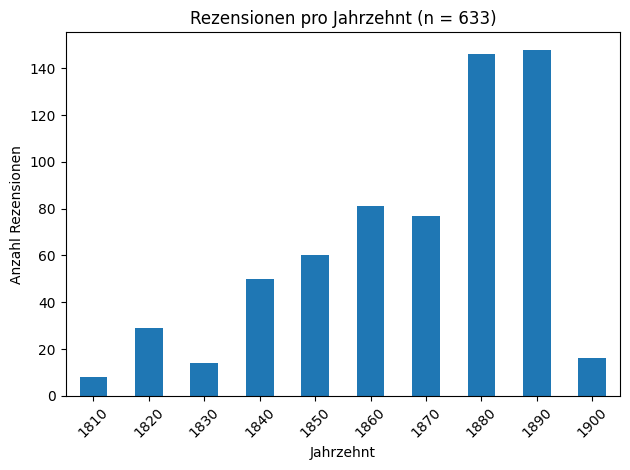

In [ ]:
plt.figure()
decade_counts.plot(kind="bar")
plt.xlabel("Jahrzehnt")
plt.ylabel("Anzahl Rezensionen")
plt.title("Rezensionen pro Jahrzehnt (n = 633)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df_review["decade_auto"] = pd.cut(df_review["year"], bins=8)  # or 9

decade_counts = df_review["decade_auto"].value_counts().sort_index()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = df_review.copy()

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["pagenumber"] = pd.to_numeric(df["pagenumber"], errors="coerce")

# standard decades
bins = list(range(1810, 1911, 10))
labels = [f"{b}s" for b in bins[:-1]]

df["decade"] = pd.cut(df["year"], bins=bins, labels=labels, right=False)

In [ ]:
decade_stats = df.groupby("decade")["pagenumber"].agg(
    mean="mean",
    median="median",
    count="count"
)

print(decade_stats)

            mean  median  count
decade                         
1810s   4.625000     4.0      8
1820s   4.931034     5.0     29
1830s   3.928571     4.0     14
1840s   2.700000     2.0     50
1850s   2.983333     3.0     60
1860s   3.259259     3.0     81
1870s   3.922078     3.0     77
1880s   4.260274     5.0    146
1890s   5.513514     6.0    148
1900s   6.375000     6.0     16


/tmp/ipykernel_2418/1911109536.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decade_stats = df.groupby("decade")["pagenumber"].agg(


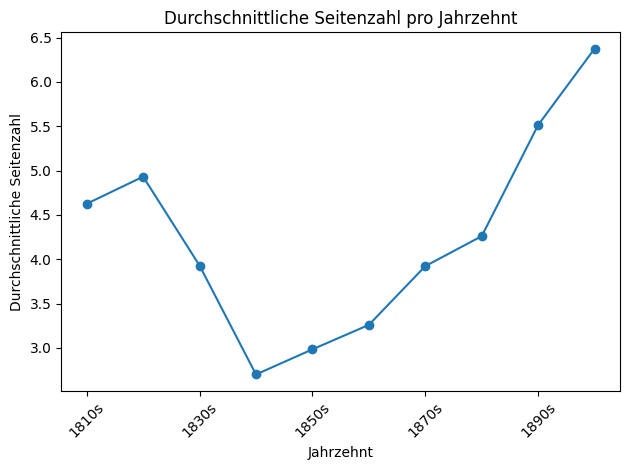

In [ ]:
plt.figure()
decade_stats["mean"].plot(marker="o")
plt.xlabel("Jahrzehnt")
plt.ylabel("Durchschnittliche Seitenzahl")
plt.title("Durchschnittliche Seitenzahl pro Jahrzehnt")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import re
import pandas as pd

def extract_tag(text, tag):
    if pd.isna(text):
        return None
    match = re.search(fr"<{tag}>(.*?)</{tag}>", text, re.DOTALL)
    return match.group(1).strip() if match else None

In [ ]:
sentiment_tags = [
    "sentiment_overall",
    "sentiment_style",
    "sentiment_content",
    "sentiment_society",
    "sentiment_morality",
    "sentiment_author"
]

for tag in sentiment_tags:
    df_review[tag] = df_review["final_dictionaries"].apply(lambda x: extract_tag(x, tag))

In [ ]:
for col in sentiment_tags:
    print(f"\n{col}")
    print(df_review[col].value_counts(dropna=False))


sentiment_overall
sentiment_overall
positive      428
ambivalent    100
neutral        66
negative       35
Name: count, dtype: int64

sentiment_style
sentiment_style
not_mentioned    421
positive         172
negative          25
ambivalent        10
neutral            1
Name: count, dtype: int64

sentiment_content
sentiment_content
positive         383
not_mentioned    150
ambivalent        51
negative          41
neutral            4
Name: count, dtype: int64

sentiment_society
sentiment_society
not_mentioned    482
positive         110
ambivalent        20
negative          16
neutral            1
Name: count, dtype: int64

sentiment_morality
sentiment_morality
not_mentioned    561
positive          42
negative          18
ambivalent         8
Name: count, dtype: int64

sentiment_author
sentiment_author
positive         311
not_mentioned    273
ambivalent        25
negative          19
neutral            1
Name: count, dtype: int64


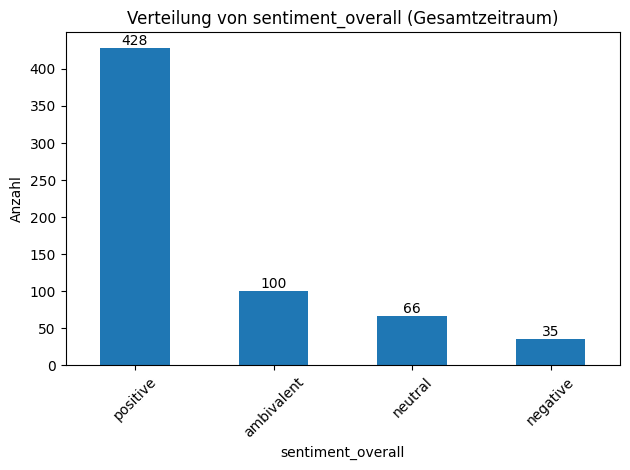

In [ ]:
import matplotlib.pyplot as plt

counts = df_review["sentiment_overall"].value_counts()

ax = counts.plot(kind="bar")

#plt.xlabel("Sentiment (gesamt)")
plt.ylabel("Anzahl")
plt.title("Verteilung von sentiment_overall (Gesamtzeitraum)")
plt.xticks(rotation=45)

# add numbers on top of bars
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()

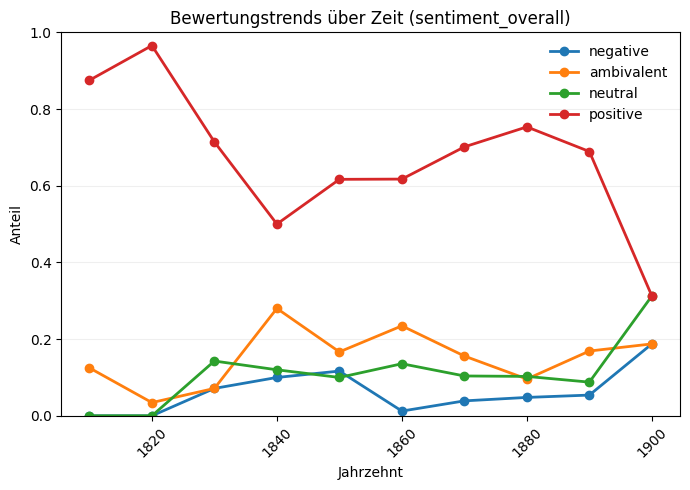

In [ ]:
sentiment_decade = (
    df_review
    .groupby(["decade", "sentiment_overall"])
    .size()
    .unstack(fill_value=0)
)

sentiment_decade_norm = sentiment_decade.div(sentiment_decade.sum(axis=1), axis=0)

import matplotlib.pyplot as plt

order = ["negative", "ambivalent", "neutral", "positive"]
sentiment_decade_norm = sentiment_decade_norm[order]

fig, ax = plt.subplots(figsize=(7, 5))

# Sentiment-Trends als Linien
for col in sentiment_decade_norm.columns:
    ax.plot(
        sentiment_decade_norm.index,
        sentiment_decade_norm[col],
        marker="o",
        linewidth=2,
        label=col
    )

ax.set_ylabel("Anteil")
ax.set_xlabel("Jahrzehnt")
ax.set_title("Bewertungstrends über Zeit (sentiment_overall)")

ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

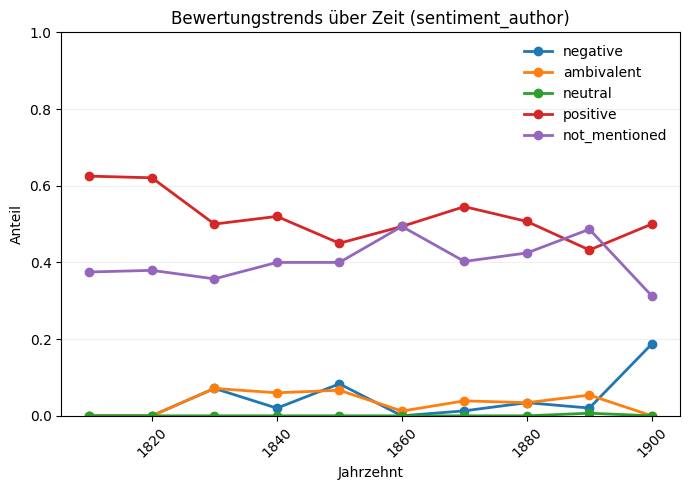

In [ ]:
sentiment_decade = (
    df_review
    .groupby(["decade", "sentiment_author"])
    .size()
    .unstack(fill_value=0)
)

sentiment_decade_norm = sentiment_decade.div(sentiment_decade.sum(axis=1), axis=0)

import matplotlib.pyplot as plt

order = ["negative", "ambivalent", "neutral", "positive", "not_mentioned"]
sentiment_decade_norm = sentiment_decade_norm[order]

fig, ax = plt.subplots(figsize=(7, 5))

# Sentiment-Trends als Linien
for col in sentiment_decade_norm.columns:
    ax.plot(
        sentiment_decade_norm.index,
        sentiment_decade_norm[col],
        marker="o",
        linewidth=2,
        label=col
    )

ax.set_ylabel("Anteil")
ax.set_xlabel("Jahrzehnt")
ax.set_title("Bewertungstrends über Zeit (sentiment_author)")

ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

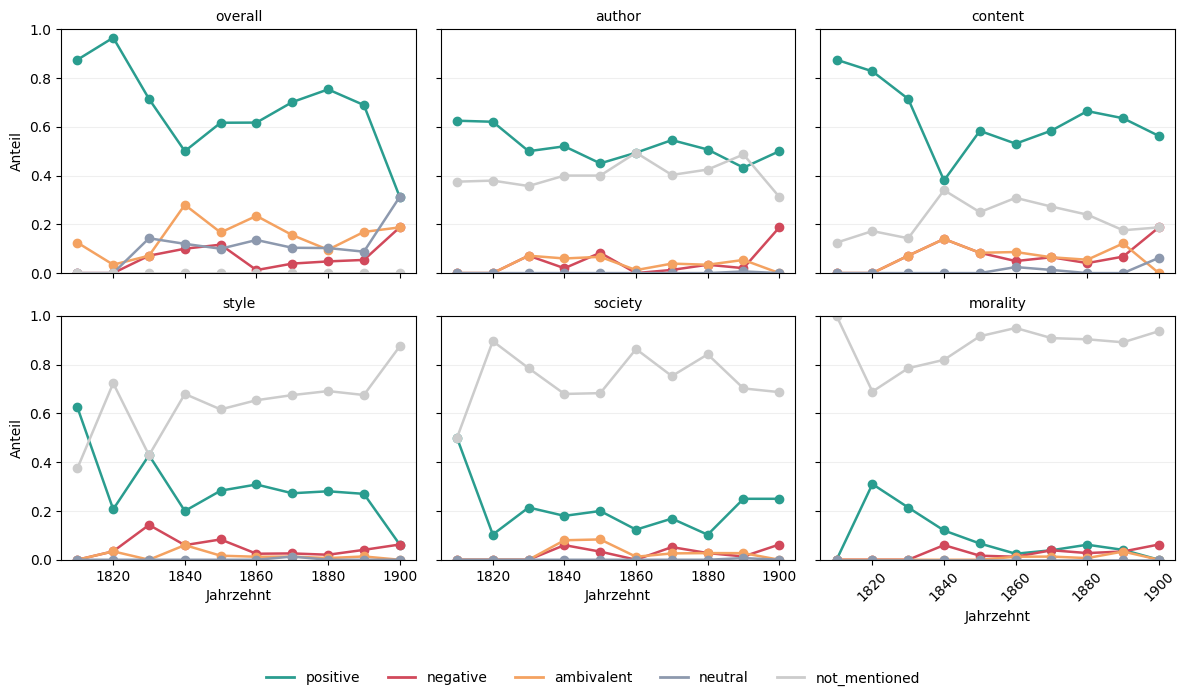

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) Einstellungen
# -----------------------------
sentiment_cols = [
    "sentiment_overall",
    "sentiment_author",
    "sentiment_content",
    "sentiment_style",
    "sentiment_society",
    "sentiment_morality"
]

order = ["positive", "negative", "ambivalent", "neutral", "not_mentioned"]

color_map = {
    "negative": "#d1495b",
    "ambivalent": "#f4a261",
    "neutral": "#8d99ae",
    "positive": "#2a9d8f",
    "not_mentioned": "#cccccc"
}

# -----------------------------
# 2) Plot vorbereiten
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True, sharey=True)
axes = axes.flatten()

# -----------------------------
# 3) Schleife über alle Sentiment-Dimensionen
# -----------------------------
for i, col in enumerate(sentiment_cols):
    ax = axes[i]

    # Aggregation
    sentiment_decade = (
        df_review
        .groupby(["decade", col])
        .size()
        .unstack(fill_value=0)
    )

    sentiment_decade_norm = sentiment_decade.div(
        sentiment_decade.sum(axis=1), axis=0
    )

    # fehlende Kategorien ergänzen
    for cat in order:
        if cat not in sentiment_decade_norm.columns:
            sentiment_decade_norm[cat] = 0

    sentiment_decade_norm = sentiment_decade_norm[order].sort_index()

    # Linienplot
    for sentiment in sentiment_decade_norm.columns:
        ax.plot(
            sentiment_decade_norm.index,
            sentiment_decade_norm[sentiment],
            marker="o",
            linewidth=1.8,
            color=color_map[sentiment]
        )

    # Titel schöner formatieren
    ax.set_title(col.replace("sentiment_", ""), fontsize=10)

    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.2)

    # Achsenbeschriftung nur außen
    if i % 3 == 0:
        ax.set_ylabel("Anteil")
    if i >= 3:
        ax.set_xlabel("Jahrzehnt")

# -----------------------------
# 4) Gemeinsame Legende
# -----------------------------
handles = [
    plt.Line2D([0], [0], color=color_map[k], lw=2)
    for k in order
]

fig.legend(
    handles,
    order,
    loc="lower center",
    ncol=5,
    frameon=False
)

# -----------------------------
# 5) Layout
# -----------------------------
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

/tmp/ipykernel_835/351441521.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=45)
/tmp/ipykernel_835/351441521.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=45)
/tmp/ipykernel_835/351441521.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=45)
/tmp/ipykernel_835/351441521.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=45)
/tmp/ipykernel_835/351441521.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fi

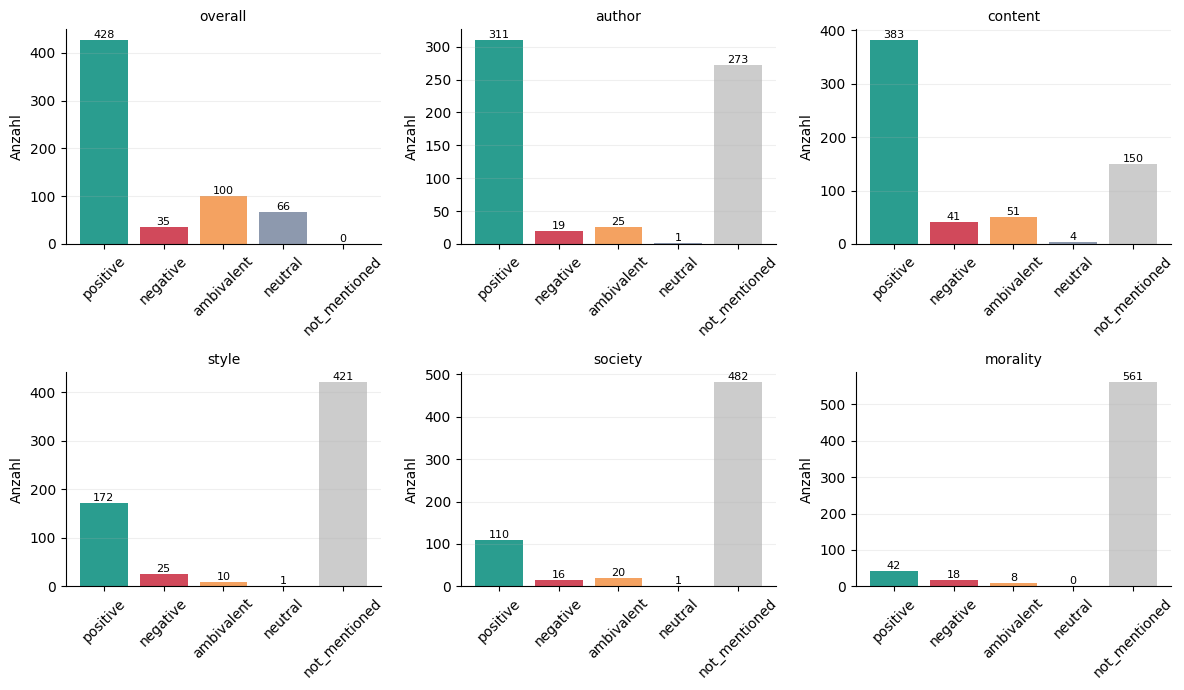

In [ ]:
import matplotlib.pyplot as plt

sentiment_cols = [
    "sentiment_overall",
    "sentiment_author",
    "sentiment_content",
    "sentiment_style",
    "sentiment_society",
    "sentiment_morality"
]

order = ["positive", "negative", "ambivalent", "neutral", "not_mentioned"]

color_map = {
    "negative": "#d1495b",
    "ambivalent": "#f4a261",
    "neutral": "#8d99ae",
    "positive": "#2a9d8f",
    "not_mentioned": "#cccccc"
}

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for i, col in enumerate(sentiment_cols):
    ax = axes[i]

    # Counts berechnen
    counts = df_review[col].value_counts()

    # fehlende Kategorien ergänzen + Reihenfolge erzwingen
    for cat in order:
        if cat not in counts:
            counts[cat] = 0
    counts = counts[order]

    # Plot
    bars = ax.bar(
        counts.index,
        counts.values,
        color=[color_map[c] for c in counts.index]
    )

    # Titel
    ax.set_title(col.replace("sentiment_", ""), fontsize=10)
    ax.set_ylabel("Anzahl")

    # Zahlen auf Bars
    for j, v in enumerate(counts.values):
        ax.text(j, v, str(int(v)), ha="center", va="bottom", fontsize=8)

    ax.set_xticklabels(counts.index, rotation=45)

    # visuell aufräumen
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.2)

# Layout
plt.tight_layout()
plt.show()

In [ ]:
author_counts = (
    df_review["author_name"]
    .dropna()
    .str.strip()
    .value_counts()
)

print(author_counts.head(20))

author_name
unknown                  96
Schiller                  4
L. von P.                 2
unbekannt                 2
Sophokles                 2
Charles Dickens           2
Gustav Freytag            2
August Koberstein         2
Karl Vogt                 2
Brigitte Augusti          2
Julius Wolff              2
Max Nordau                2
Georg v. Oertzen          2
Karl Gutzkow              2
Paul Heyse                2
Friedrich Rückert         2
Theodor Storm             2
Wolfgang Müller           2
Heinrich Bone             2
Dr. Rudolf Pfleiderer     2
Name: count, dtype: int64


In [ ]:
df_review["author_norm"] = (
    df_review["author_name"]
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

In [ ]:
df_review["author_lastname"] = (
    df_review["author_norm"]
    .str.split()
    .str[-1]
)

In [ ]:
lastname_counts = df_review["author_lastname"].value_counts()
print(lastname_counts.head(20))

author_lastname
unknown        96
müller          6
schiller        4
bädeker         3
meyer           3
gutzkow         3
rückert         3
proudhon        3
dickens         3
wolff           3
bone            2
heyse           2
schücking       2
wildenbruch     2
p.              2
storm           2
pfleiderer      2
spemann         2
koberstein      2
nansen          2
Name: count, dtype: int64


In [ ]:
gender_counts = (
    df_review["author_gender"]
    .fillna("unknown")
    .value_counts()
)

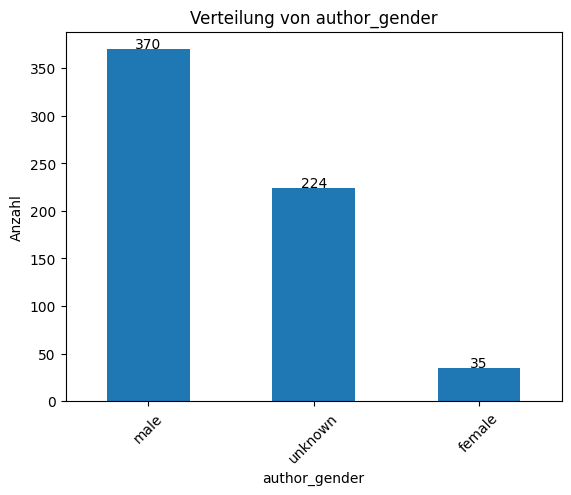

In [ ]:
import matplotlib.pyplot as plt

ax = gender_counts.plot(kind="bar")

plt.ylabel("Anzahl")
plt.title("Verteilung von author_gender")
plt.xticks(rotation=45)

# Werte über die Balken schreiben
for i, v in enumerate(gender_counts):
    ax.text(i, v + 0.5, str(v), ha="center")

plt.show()

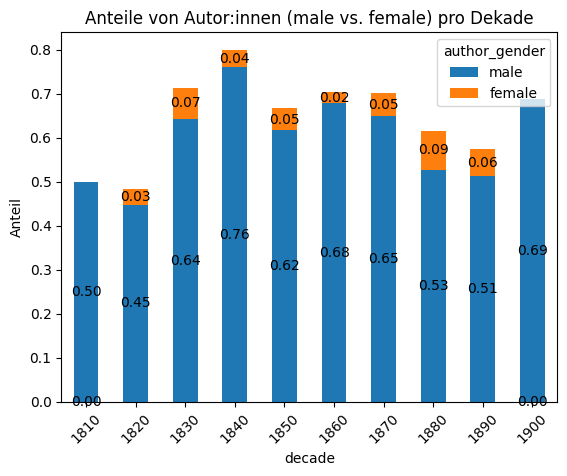

In [ ]:
prop_table = pd.crosstab(
    df_review["decade"],
    df_review["author_gender"].str.lower().str.strip(),
    normalize="index"
)

prop_table = prop_table[["male", "female"]]

prop_table = prop_table.reindex(columns=["male", "female"])

import matplotlib.pyplot as plt

ax = prop_table.plot(kind="bar", stacked=True)

plt.ylabel("Anteil")
plt.title("Anteile von Autor:innen (male vs. female) pro Dekade")
plt.xticks(rotation=45)

# Prozentwerte anzeigen
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="center")

plt.legend(title="author_gender")
plt.show()

In [ ]:
voice_counts = (
    df_review["reviewer_voice"]
    .fillna("unknown")
    .str.lower()
    .str.strip()
    .value_counts()
)

print(voice_counts)

reviewer_voice
impersonal               586
first_person_plural       28
first_person_singular     15
Name: count, dtype: int64


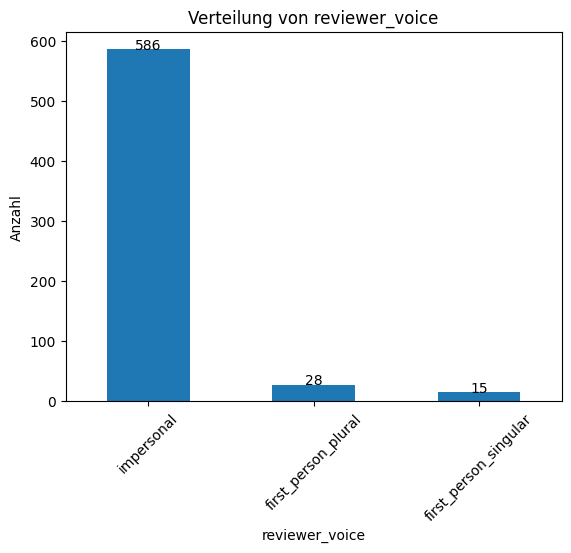

In [ ]:
import matplotlib.pyplot as plt

ax = voice_counts.plot(kind="bar")

plt.ylabel("Anzahl")
plt.title("Verteilung von reviewer_voice")
plt.xticks(rotation=45)

# Werte über die Balken schreiben
for i, v in enumerate(voice_counts):
    ax.text(i, v + 0.5, str(v), ha="center")

plt.show()

In [ ]:
prop_table = pd.crosstab(
    df_review["decade"],
    df_review["reviewer_voice"].fillna("unknown").str.lower().str.strip(),
    normalize="index"
)

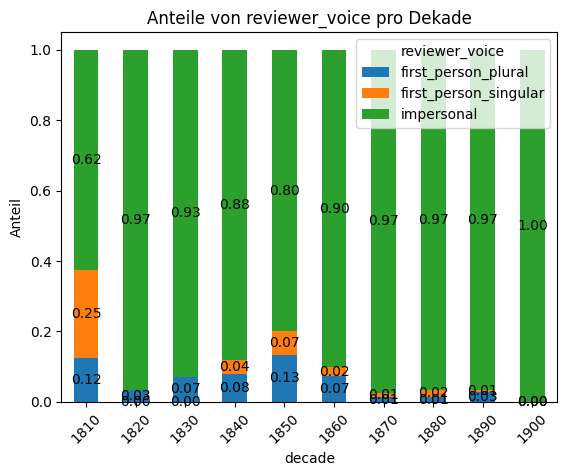

In [ ]:
import matplotlib.pyplot as plt

ax = prop_table.plot(kind="bar", stacked=True)

plt.ylabel("Anteil")
plt.title("Anteile von reviewer_voice pro Dekade")
plt.xticks(rotation=45)

# Labels (optional, kann bei vielen Kategorien unübersichtlich werden)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="center")

plt.legend(title="reviewer_voice")
plt.show()

In [ ]:
category_counts = (
    df_review["category"]
    .fillna("unknown")
    .str.strip()
    .value_counts()
)

print(category_counts.head(20))

category
Belletristik          269
Gelehrte Literatur    253
Gebrauchsliteratur    107
Name: count, dtype: int64


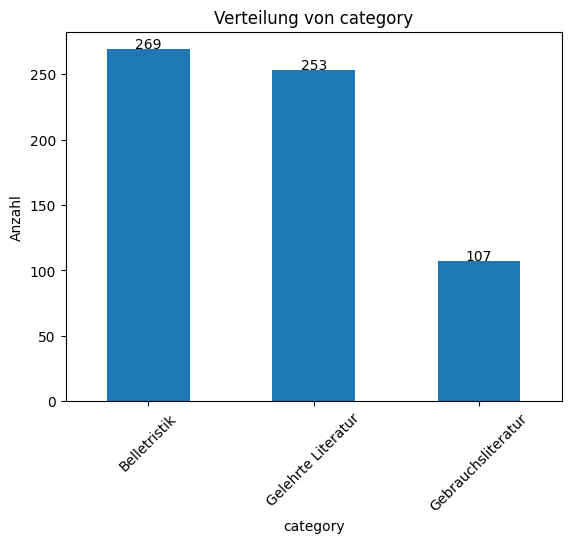

In [ ]:
import matplotlib.pyplot as plt

ax = category_counts.plot(kind="bar")

plt.ylabel("Anzahl")
plt.title("Verteilung von category")
plt.xticks(rotation=45)

# Werte über die Balken schreiben
for i, v in enumerate(category_counts):
    ax.text(i, v + 0.5, str(v), ha="center")

plt.show()

In [ ]:
prop_table = pd.crosstab(
    df_review["decade"],
    df_review["category"].fillna("unknown").str.strip(),
    normalize="index"
)

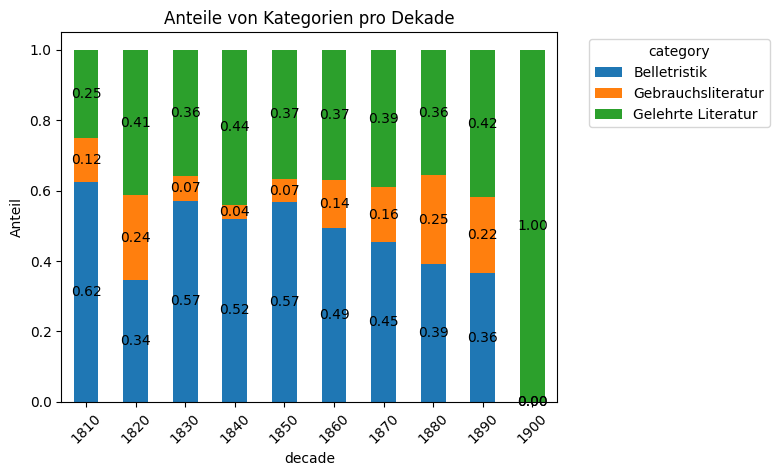

In [ ]:
import matplotlib.pyplot as plt

ax = prop_table.plot(kind="bar", stacked=True)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="center")
plt.ylabel("Anteil")
plt.title("Anteile von Kategorien pro Dekade")
plt.xticks(rotation=45)

plt.legend(title="category", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

In [ ]:
genre_counts = (
    df_review["genre"]
    .fillna("unknown")
    .str.strip()
    .value_counts()
)

print(genre_counts.head(20))

genre
Wissenschaftliche Abhandlung    147
Schrift                          74
Erzählung                        74
Roman                            53
other                            46
Essay                            45
Lyrik                            45
Ratgeber                         32
Drama                            28
Lehrbuch                         22
Kalender/Almanach                22
Lexikon                          20
Novelle                          11
unknown                           9
Biographie                        1
Name: count, dtype: int64


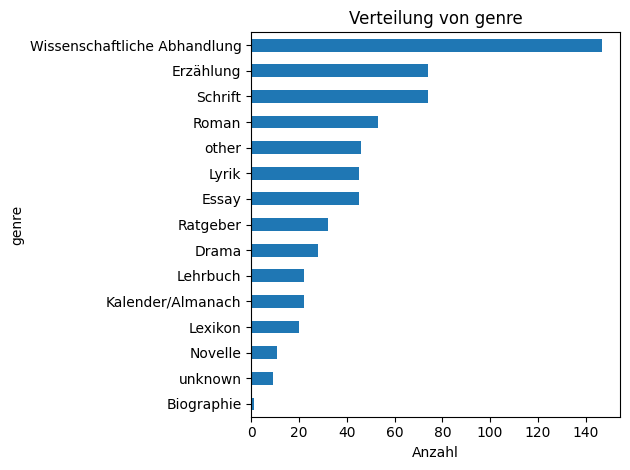

In [ ]:
import matplotlib.pyplot as plt

genre_counts = (
    df_review["genre"]
    .fillna("unknown")
    .str.strip()
    .value_counts()
)

ax = genre_counts.sort_values().plot(kind="barh")

plt.xlabel("Anzahl")
plt.title("Verteilung von genre")

plt.tight_layout()
plt.show()

In [ ]:
prop_table = pd.crosstab(
    df_review["decade"],
    df_review["genre"].fillna("unknown").str.strip(),
    normalize="index"
)

In [ ]:
top_genres = (
    df_review["genre"]
    .fillna("unknown")
    .str.strip()
    .value_counts()
    .head(8)
    .index
)

prop_table = prop_table[top_genres].reindex(columns=top_genres)

In [ ]:
genres_focus = ["Novelle", "Roman", "Drama", "Lyrik", "Erzählung"]

df_focus = df_review[
    df_review["genre"].isin(genres_focus)
].copy()

In [ ]:
prop_table = pd.crosstab(
    df_focus["decade"],
    df_focus["genre"],
    normalize="index"
).reindex(columns=genres_focus)

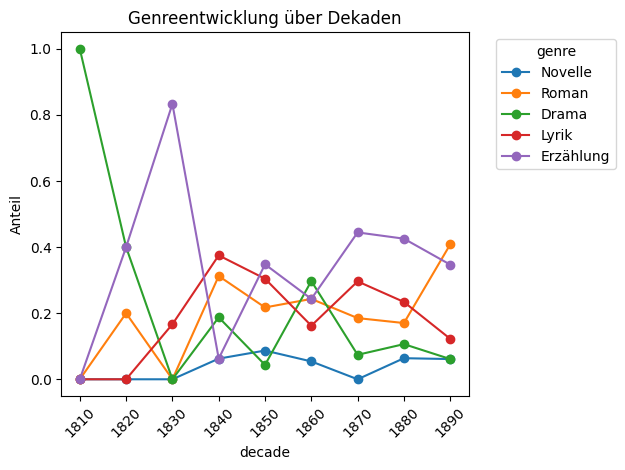

In [ ]:
import matplotlib.pyplot as plt

ax = prop_table.plot(kind="line", marker="o")

plt.ylabel("Anteil")
plt.title("Genreentwicklung über Dekaden")

plt.xticks(rotation=45)

plt.legend(title="genre", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

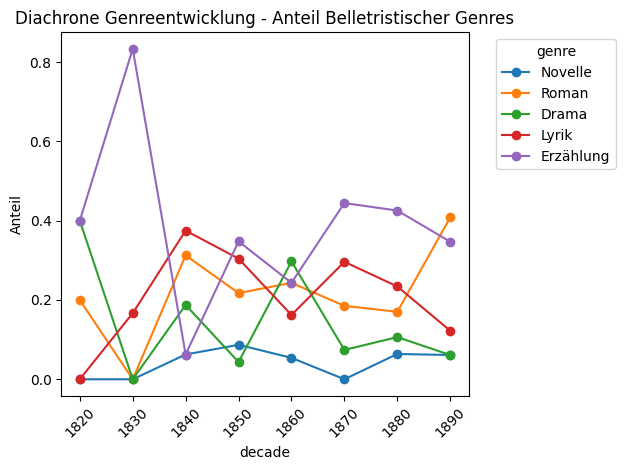

In [ ]:
df_focus = df_review[
    df_review["genre"].isin(["Novelle", "Roman", "Drama", "Lyrik", "Erzählung"])
].copy()

df_focus = df_focus[df_focus["decade"] != 1810]

prop_table = pd.crosstab(
    df_focus["decade"],
    df_focus["genre"],
    normalize="index"
).reindex(columns=["Novelle", "Roman", "Drama", "Lyrik", "Erzählung"])

import matplotlib.pyplot as plt

ax = prop_table.plot(kind="line", marker="o")

plt.ylabel("Anteil")
plt.title("Diachrone Genreentwicklung - Anteil Belletristischer Genres")

plt.xticks(rotation=45)

plt.legend(title="genre", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
df_review = pd.read_csv("df_reviews_with_all_columns.csv")

In [ ]:
translation_counts = (
    df_review["is_translation"]
    .fillna("unknown")
    .str.lower()
    .str.strip()
    .value_counts()
)


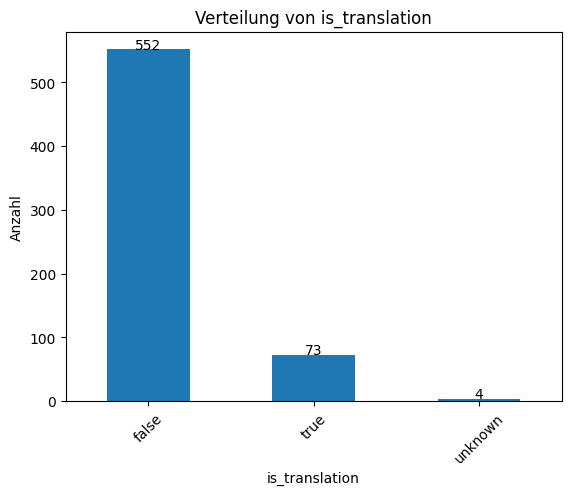

In [ ]:
import matplotlib.pyplot as plt
ax = translation_counts.plot(kind="bar")

plt.ylabel("Anzahl")
plt.title("Verteilung von is_translation")
plt.xticks(rotation=45)

# Werte über die Balken schreiben
for i, v in enumerate(translation_counts):
    ax.text(i, v + 0.5, str(v), ha="center")

plt.show()


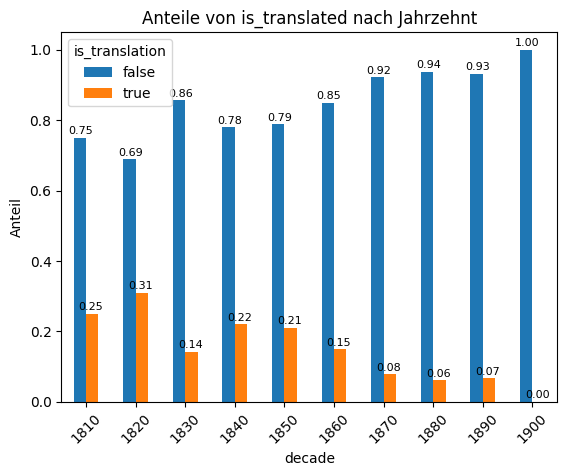

In [ ]:
import matplotlib.pyplot as plt

# unknown entfernen
df_filtered = df_review[df_review["is_translation"] != "unknown"]

# Gruppieren nach decade und is_translated
counts = df_filtered.groupby(["decade", "is_translation"]).size().unstack(fill_value=0)

# In Proportionen umwandeln (pro Jahrzehnt normieren)
proportions = counts.div(counts.sum(axis=1), axis=0)

# Plot
ax = proportions.plot(kind="bar")

plt.ylabel("Anteil")
plt.title("Anteile von is_translated nach Jahrzehnt")
plt.xticks(rotation=45)

# Werte über die Balken schreiben
for i, row in enumerate(proportions.values):
    for j, val in enumerate(row):
        ax.text(i + (j - 0.5) * 0.2, val + 0.01, f"{val:.2f}", ha="center", fontsize=8)

plt.show()

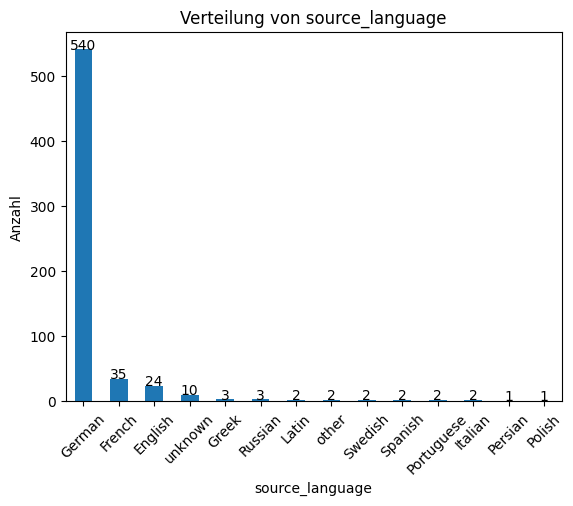

In [ ]:
import matplotlib.pyplot as plt

# Häufigkeiten zählen (ohne NaN)
language_counts = df_review["source_language"].value_counts()

ax = language_counts.plot(kind="bar")

plt.ylabel("Anzahl")
plt.title("Verteilung von source_language")
plt.xticks(rotation=45)

# Werte über die Balken schreiben
for i, v in enumerate(language_counts):
    ax.text(i, v + 0.5, str(v), ha="center")

plt.show()

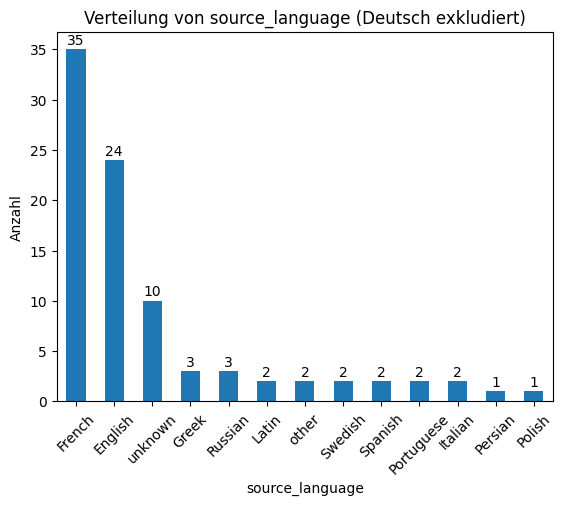

In [ ]:
import matplotlib.pyplot as plt

# "German" ausschließen + NaN entfernen
language_counts = df_review[df_review["source_language"] != "German"]["source_language"].value_counts()

ax = language_counts.plot(kind="bar")

plt.ylabel("Anzahl")
plt.title("Verteilung von source_language (Deutsch exkludiert)")
plt.xticks(rotation=45)

# Werte über die Balken schreiben
for i, v in enumerate(language_counts):
    ax.text(i, v + 0.5, str(v), ha="center")

plt.show()

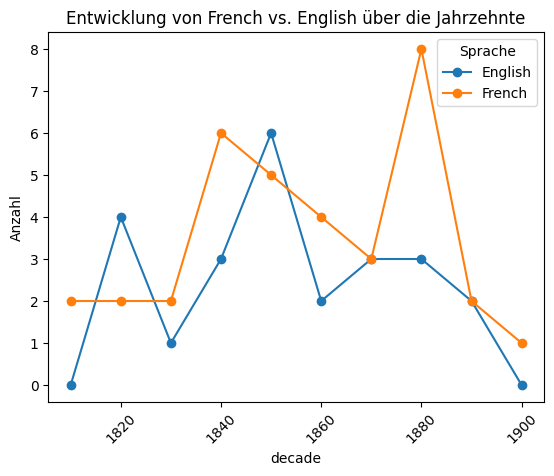

In [ ]:
import matplotlib.pyplot as plt

# Filter: nur French & English, ohne NaN
df_filtered = df_review[
    df_review["source_language"].isin(["French", "English"])
]

# Gruppieren nach decade und Sprache
language_by_decade = (
    df_filtered
    .groupby(["decade", "source_language"])
    .size()
    .unstack(fill_value=0)
)

# Plot als Linienchart (besser für Entwicklung)
ax = language_by_decade.plot(kind="line", marker="o")

plt.ylabel("Anzahl")
plt.title("Entwicklung von French vs. English über die Jahrzehnte")
plt.xticks(rotation=45)

plt.legend(title="Sprache")
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_filtered = df_review[
    df_review["author_gender"].isin(["male", "female"])
]

In [ ]:
gender_sentiment = pd.crosstab(
    df_filtered["author_gender"],
    df_filtered["sentiment_overall"]
)

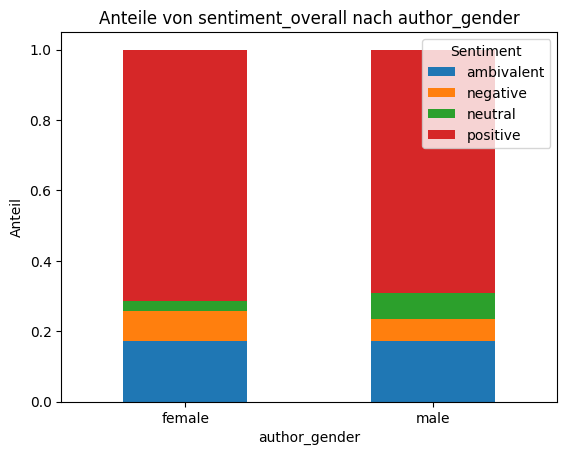

In [ ]:
gender_sentiment_prop = gender_sentiment.div(gender_sentiment.sum(axis=1), axis=0)

ax = gender_sentiment_prop.plot(kind="bar", stacked=True)

plt.ylabel("Anteil")
plt.title("Anteile von sentiment_overall nach author_gender")
plt.xticks(rotation=0)

plt.legend(title="Sentiment")
plt.show()

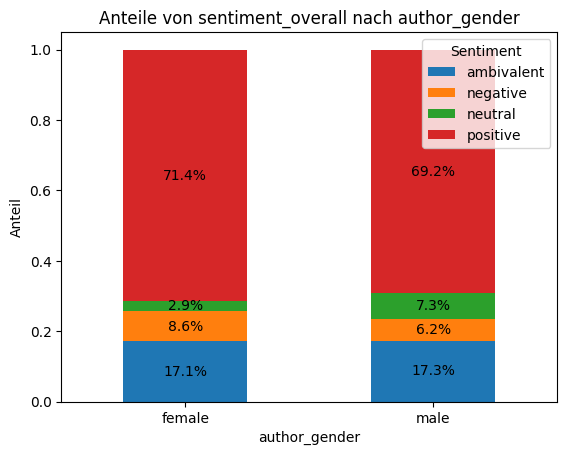

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter
df_filtered = df_review[
    df_review["author_gender"].isin(["male", "female"])
]

# Kreuztabelle
gender_sentiment = pd.crosstab(
    df_filtered["author_gender"],
    df_filtered["sentiment_overall"]
)

# In Anteile umwandeln
gender_sentiment_prop = gender_sentiment.div(gender_sentiment.sum(axis=1), axis=0)

# Plot
ax = gender_sentiment_prop.plot(kind="bar", stacked=True)

plt.ylabel("Anteil")
plt.title("Anteile von sentiment_overall nach author_gender")
plt.xticks(rotation=0)

# Prozentwerte in die Balken schreiben
for i, (index, row) in enumerate(gender_sentiment_prop.iterrows()):
    cumulative = 0
    for value in row:
        if value > 0:
            ax.text(
                i,
                cumulative + value / 2,
                f"{value*100:.1f}%",
                ha="center",
                va="center"
            )
            cumulative += value

plt.legend(title="Sentiment")
plt.show()

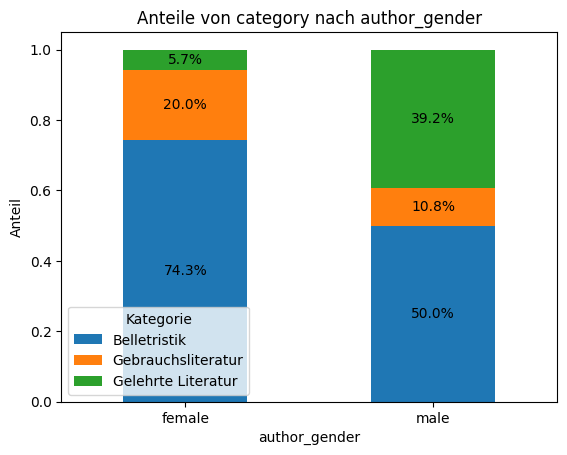

In [ ]:
gender_category = pd.crosstab(
    df_filtered["author_gender"],
    df_filtered["category"]
)

gender_category_prop = gender_category.div(gender_category.sum(axis=1), axis=0)

ax = gender_category_prop.plot(kind="bar", stacked=True)

plt.ylabel("Anteil")
plt.title("Anteile von category nach author_gender")
plt.xticks(rotation=0)

# Prozentwerte einzeichnen
for i, (index, row) in enumerate(gender_category_prop.iterrows()):
    cumulative = 0
    for value in row:
        if value > 0.03:  # optional: nur anzeigen, wenn >3%
            ax.text(
                i,
                cumulative + value / 2,
                f"{value*100:.1f}%",
                ha="center",
                va="center"
            )
        cumulative += value

plt.legend(title="Kategorie")
plt.show()

In [ ]:
counts = {}
for col in sentiment_cols:
    counts[col] = df_female[col][df_female[col] != "not_mentioned"].value_counts()

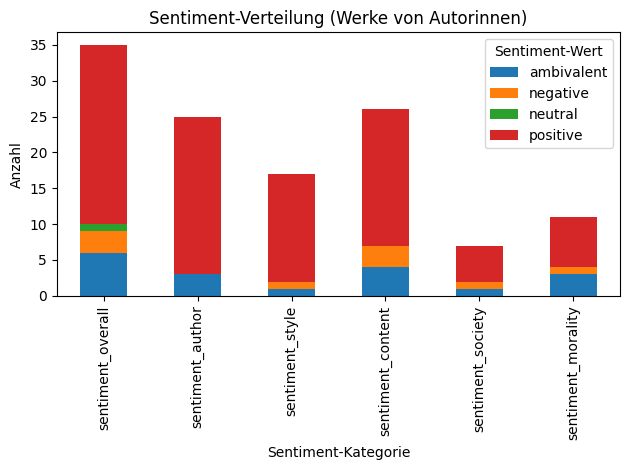

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Subset
df_female = df_review[df_review["author_gender"] == "female"]

# 2. Relevante Spalten
sentiment_cols = [
    "sentiment_overall",
    "sentiment_author",
    "sentiment_style",
    "sentiment_content",
    "sentiment_society",
    "sentiment_morality"
]

# 3. Counts pro Spalte berechnen
counts = {}
for col in sentiment_cols:
    counts[col] = df_female[col][df_female[col] != "not_mentioned"].value_counts()

# 4. In DataFrame umwandeln (Spalten = Kategorien, Zeilen = Sentimentwerte)
df_counts = pd.DataFrame(counts).fillna(0)

# Optional: gleiche Reihenfolge der Sentimentwerte erzwingen
df_counts = df_counts.sort_index()

# 5. Plot
df_counts.T.plot(kind="bar", stacked=True)

plt.xlabel("Sentiment-Kategorie")
plt.ylabel("Anzahl")
plt.title("Sentiment-Verteilung (Werke von Autorinnen)")
plt.legend(title="Sentiment-Wert")
plt.tight_layout()
plt.show()

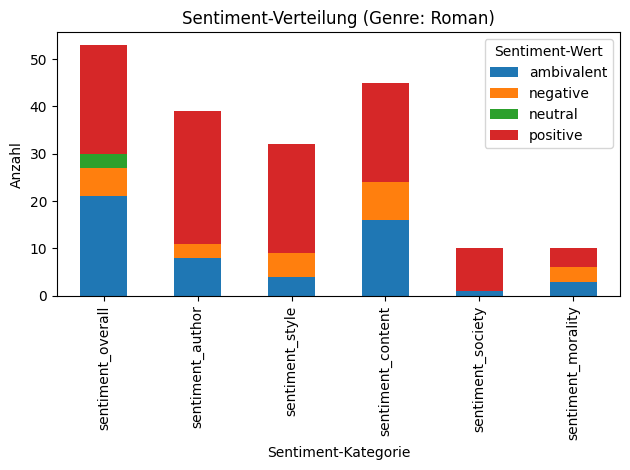

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Subset
df_roman = df_review[df_review["genre"] == "Roman"]

# 2. Relevante Spalten
sentiment_cols = [
    "sentiment_overall",
    "sentiment_author",
    "sentiment_style",
    "sentiment_content",
    "sentiment_society",
    "sentiment_morality"
]

# 3. Counts ohne "not_mentioned"
counts = {
    col: df_roman[col].loc[df_roman[col] != "not_mentioned"].value_counts()
    for col in sentiment_cols
}

# 4. In DataFrame umwandeln
df_counts = pd.DataFrame(counts).fillna(0).sort_index()

# 5. Plot
df_counts.T.plot(kind="bar", stacked=True)

plt.xlabel("Sentiment-Kategorie")
plt.ylabel("Anzahl")
plt.title("Sentiment-Verteilung (Genre: Roman)")
plt.legend(title="Sentiment-Wert")
plt.tight_layout()
plt.show()

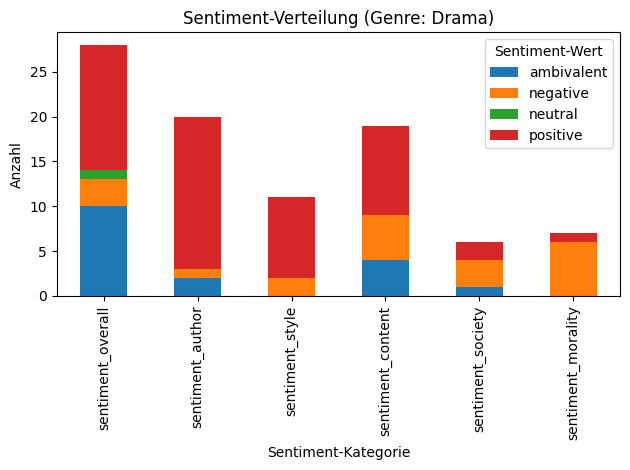

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Subset
df_drama = df_review[df_review["genre"] == "Drama"]

# 2. Relevante Spalten
sentiment_cols = [
    "sentiment_overall",
    "sentiment_author",
    "sentiment_style",
    "sentiment_content",
    "sentiment_society",
    "sentiment_morality"
]

# 3. Counts ohne "not_mentioned"
counts = {
    col: df_drama[col].loc[df_drama[col] != "not_mentioned"].value_counts()
    for col in sentiment_cols
}

# 4. In DataFrame umwandeln
df_counts = pd.DataFrame(counts).fillna(0).sort_index()

# 5. Plot
df_counts.T.plot(kind="bar", stacked=True)

plt.xlabel("Sentiment-Kategorie")
plt.ylabel("Anzahl")
plt.title("Sentiment-Verteilung (Genre: Drama)")
plt.legend(title="Sentiment-Wert")
plt.tight_layout()
plt.show()